## ANÁLISIS DEL CORPUS

En este cuaderno se realiza un estudio sobre las propiedades, características y otros datos de interés que podemos obtener del Corpus Completo.

Todas las funciones utilizadas para realizar la mayoría de los cálculos y gráficos este apartado se encuentran en este [script de python](funciones_estadisticos.py).

In [1]:
import pandas as pd
from funciones_estadisticos import *

In [2]:
book_submissions, book_comments = separar_dataframes('completo_books.json')
jobs_submissions, jobs_comments = separar_dataframes('completo_jobs.json')
lol_submissions, lol_comments = separar_dataframes('completo_LeagueOfLegends.json')
random_submissions, random_comments = separar_dataframes('completo_RandomThoughts.json')
travel_submissions, travel_comments = separar_dataframes('completo_travel.json')
unpopular_submissions, unpopular_comments = separar_dataframes('completo_unpopularopinion.json')

lista_dataframes = [book_submissions, book_comments, jobs_submissions, jobs_comments, lol_submissions, lol_comments,
					random_submissions, random_comments, travel_submissions, travel_comments, unpopular_submissions, unpopular_comments]

lista_dataframes_comentarios = [book_comments, jobs_comments, lol_comments, random_comments, travel_comments, unpopular_comments]

display(book_submissions.head())
display(book_comments.head())

,author,created_utc,id,name,num_comments,score,selftext,subreddit,title,created_datetime,id_hilo_limpio
0,kimmisy,1.742420e+09,1jf8hdb,t3_1jf8hdb,255,675,I’m so tired of seeing this ending. In the boo...,books,I’m sick of badass FMC having a « happy ending...,2025-03-19T21:34:03+00:00,0
1,lydocia,1.738822e+09,1iivxkz,t3_1iivxkz,350,124,"Way back when, the books I used to read all ha...",books,When did authors stop giving chapters individu...,2025-02-06T06:07:23+00:00,1
2,sofbunny,1.739574e+09,1ipnh8i,t3_1ipnh8i,1476,5842,"To be more specific, chapters 19 and 21, when ...",books,We were assigned The Grapes of Wrath in high s...,2025-02-14T22:57:49+00:00,2
3,Raj_Valiant3011,1.736711e+09,1hzv1nf,t3_1hzv1nf,190,55,"I was recently reading Fyodor Dostoevsky's, Cr...",books,What are some books who have an unreliable nar...,2025-01-12T19:44:44+00:00,3
4,tambitoast,1.742316e+09,1je9imj,t3_1je9imj,948,309,I was wondering if there has ever been any rea...,books,What's the pettiest reason you've been mad at ...,2025-03-18T16:46:46+00:00,4


,author,body,controversiality,created_utc,id,link_id,parent_id,score,subreddit,created_datetime
0,kimmisy,"Thanks! I’ve heard of that before, I’ll defini...",0,1.742420e+09,miox56e,t3_1jf8hdb,t1_miowxfi,1,books,2025-03-19T21:41:27+00:00
1,IAmThePonch,Check out mistborn then op,1,1.742420e+09,miowxfi,t3_1jf8hdb,t3_1jf8hdb,2,books,2025-03-19T21:40:23+00:00
2,kimmisy,"Very curious, what books would you recommend? ...",0,1.742420e+09,miowzgo,t3_1jf8hdb,t1_miowqqg,23,books,2025-03-19T21:40:39+00:00
3,zaccus,If a man settles down and has a family does th...,0,1.742421e+09,miox9sw,t3_1jf8hdb,t3_1jf8hdb,24,books,2025-03-19T21:42:08+00:00
4,sabla,That's why I loved Tamora Pierce's Tortall ser...,0,1.742421e+09,mioydfb,t3_1jf8hdb,t3_1jf8hdb,350,books,2025-03-19T21:47:43+00:00


In [3]:
histograma(lista_dataframes)

In [4]:
lista_dataframes_metricas = metricas_a_df(lista_dataframes_comentarios, 'body')

metricas_generales = calcular_estadisticos_corpus(lista_dataframes_metricas)

Calculando métricas para 1180 filas de r/books...
Calculando métricas para 1180 filas de r/jobs...
Calculando métricas para 1180 filas de r/leagueoflegends...
Calculando métricas para 1180 filas de r/RandomThoughts...
Calculando métricas para 1180 filas de r/travel...
Calculando métricas para 1180 filas de r/unpopularopinion...
✅ ¡Todas las métricas calculadas!


In [5]:
display(metricas_generales)

,Subreddit,Comentarios,Total Palabras,Total Tokens,Total Frases,Media Palabras/Coment.,Media Frases/Coment.,Media Palabras/Frase,Riqueza Léxica Media (TTR %)
0,r/books,1180,44073,51704,3203,37.35,2.71,13.71,87.49
1,r/jobs,1180,40932,47713,3211,34.69,2.72,12.45,88.98
2,r/travel,1180,40674,47460,3148,34.47,2.67,12.49,88.66
3,r/unpopularopinion,1180,35453,41101,2668,30.04,2.26,13.03,89.66
4,r/leagueoflegends,1180,32460,36742,2239,27.51,1.90,14.31,91.35
5,r/RandomThoughts,1180,21852,25690,2013,18.52,1.71,10.60,92.53


In [6]:
metricas = ['palabras','frases','palabras_por_frase','ttr']
for i in range(len(metricas)):
	boxplot(lista_dataframes_metricas, metrica=metricas[i])

In [7]:
plot_top_ngramas(lista_dataframes, n=2, top_k=15, columna_texto='body')

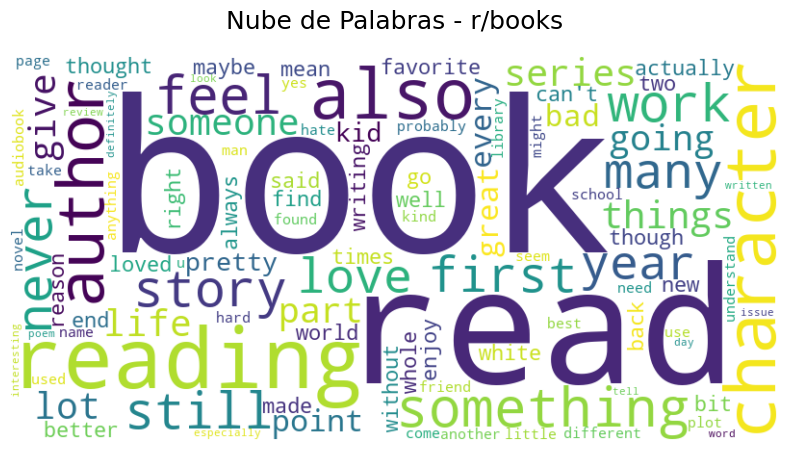

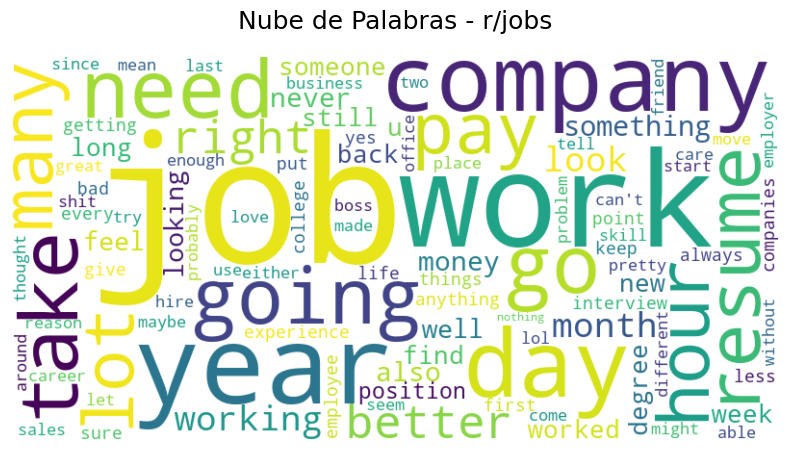

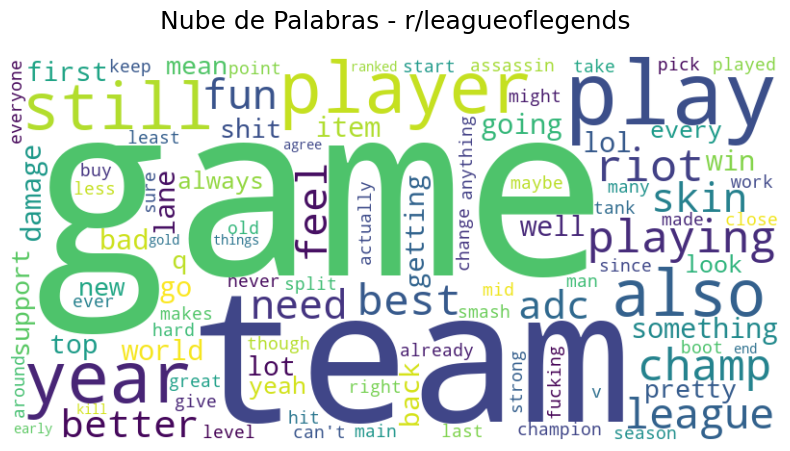

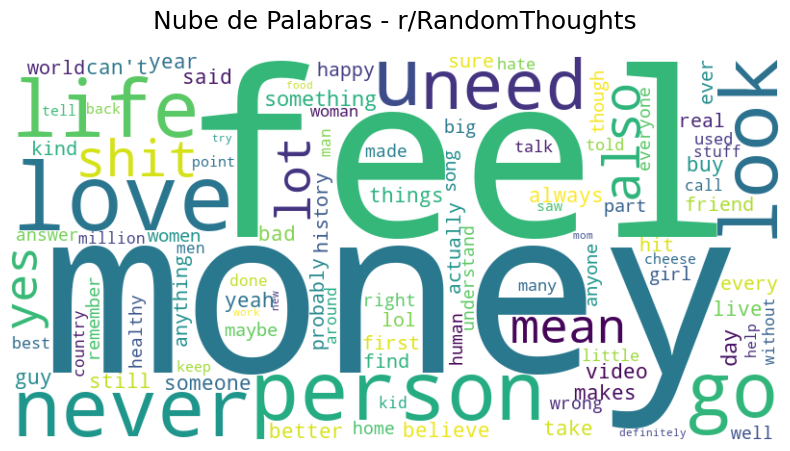

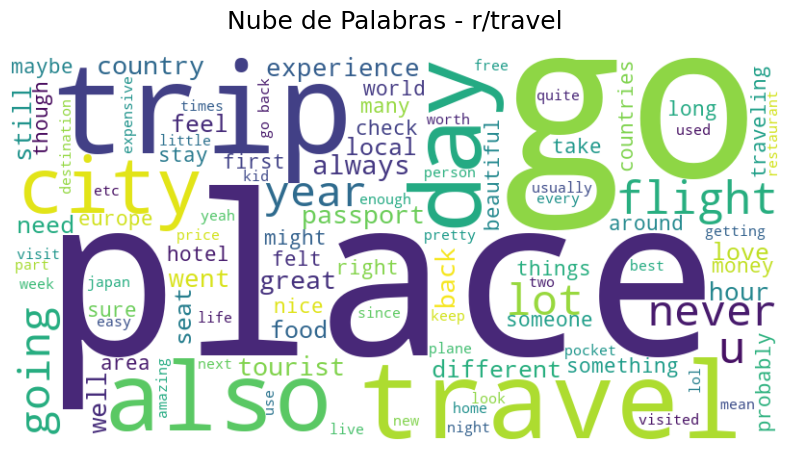

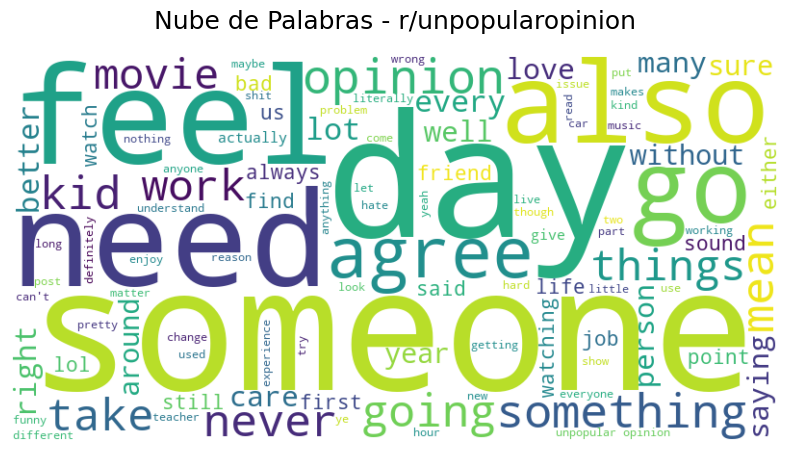

In [8]:
plot_wordclouds(lista_dataframes, columna_texto='body')

In [9]:
plot_scatter_longitud_score(lista_dataframes_metricas, columna_longitud='palabras')

In [10]:
from langdetect import detect
import re

diccionario_idiomas = {
	'en': 'Inglés',
	'es': 'Español',
	'fr': 'Francés',
	'de': 'Alemán',
	'it': 'Italiano'
}
def deteccion_segura(texto):
	if not texto or not re.search('[a-zA-Z]', str(texto)):
		return 'unknown'
	
	try:
		return detect(texto)
	except:
		return 'unknown'

for df in lista_dataframes:
	if 'body' in df.columns:
		df['language_code'] = df['body'].apply(deteccion_segura)
		df['language'] = df['language_code'].apply(lambda x: diccionario_idiomas.get(x, 'Otro') if isinstance(x, str) and len(x) > 0 else 'unknown')
	else:
		df['language_code'] = df['title'].apply(deteccion_segura)
		df['language'] = df['language_code'].apply(lambda x: diccionario_idiomas.get(x, 'Otro') if isinstance(x, str) and len(x) > 0 else 'unknown')

plot_pie(lista_dataframes, columna='language', titulo='Distribucion de Idiomas en el Corpus')

<Figure size 800x800 with 0 Axes>

In [11]:
barplot(lista_dataframes)